# 🎯 FAISS для Информационно-Поисковых Систем
## Курс: Информационно-поисковые системы

### Цели занятия:
- Понять принципы работы FAISS (Facebook AI Similarity Search)
- Научиться создавать различные типы индексов FAISS
- Реализовать быстрый семантический поиск на больших коллекциях
- Сравнить производительность разных типов индексов
- Экспериментировать с параметрами поиска

---

## 📚 Теоретическая справка

**FAISS** (Facebook AI Similarity Search) — библиотека для эффективного поиска похожих векторов и кластеризации, разработанная Facebook AI Research.

### Ключевые особенности:
1. **Масштабируемость** — работает с миллиардами векторов
2. **Скорость** — оптимизированные алгоритмы на CPU и GPU
3. **Гибкость** — множество типов индексов для разных задач
4. **Сжатие** — методы квантования для экономии памяти

### Типы индексов FAISS:
- **IndexFlatL2** — точный поиск по евклидову расстоянию
- **IndexFlatIP** — точный поиск по скалярному произведению
- **IndexIVFFlat** — инвертированный файл с кластеризацией
- **IndexHNSW** — графовый индекс для быстрого поиска
- **IndexPQ** — продуктное квантование для сжатия

### Применение в ИПС:
- Семантический поиск документов
- Поиск похожих запросов
- Кластеризация результатов
- Рекомендательные системы

---

## ⚙️ Требования
- Google Colab с GPU (рекомендуется для больших коллекций)
- Библиотеки: faiss-cpu, sentence-transformers, scikit-learn

In [1]:
# @title 🔧 1. Импорт библиотек и проверка окружения

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import random
import warnings
warnings.filterwarnings('ignore')

# Проверка и установка FAISS
try:
    import faiss
    print("✅ FAISS уже установлен")
except ImportError:
    print("🔄 Установка FAISS...")
    !pip install faiss-cpu
    import faiss

print(f"✅ FAISS версия: {faiss.__version__}")

# Проверка PyTorch и GPU
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"✅ Используемое устройство: {device}")
print(f"✅ PyTorch версия: {torch.__version__}")

# Для красивых визуализаций
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Информация о памяти
if device == 'cuda':
    print(f"📊 Доступная память GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("📊 Работа на CPU")

print("\n✅ Шаг 1 завершён: Библиотеки импортированы")

🔄 Установка FAISS...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 47.3 MB/s eta 0:00:00
✅ FAISS версия: 1.13.2
✅ Используемое устройство: cuda
✅ PyTorch версия: 2.10.0+cu128
📊 Доступная память GPU: 15.64 GB

✅ Шаг 1 завершён: Библиотеки импортированы


In [2]:
# @title 📥 2. Загрузка модели для получения эмбеддингов

from sentence_transformers import SentenceTransformer

print("🔄 Загрузка модели Sentence-Transformers...")
print("💡 Первый запуск может занять 1-2 минуты (загрузка модели)")

# Используем легковесную модель для скорости
#model_name = 'sentence-transformers/all-MiniLM-L6-v2'
model_name = 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
model = SentenceTransformer(model_name)

print(f"✅ Модель загружена: {model_name}")
print(f"📊 Размерность эмбеддингов: {model.get_sentence_embedding_dimension()}")

print("\n✅ Шаг 2 завершён: Модель готова")

🔄 Загрузка модели Sentence-Transformers...
💡 Первый запуск может занять 1-2 минуты (загрузка модели)


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Модель загружена: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
📊 Размерность эмбеддингов: 384

✅ Шаг 2 завершён: Модель готова


In [3]:
# @title 📚 3. Создание тестовой коллекции документов

# Генерация большой коллекции документов для демонстрации масштабируемости
def generate_documents(n_docs=500):
    """Генерирует тестовые документы по темам"""
    topics = [
        "машинное обучение и искусственный интеллект",
        "поисковые системы и информационный поиск",
        "обработка естественного языка и текстовая аналитика",
        "нейронные сети и глубокое обучение",
        "базы данных и управление информацией",
        "веб-технологии и интернет-сервисы",
        "компьютерное зрение и распознавание образов",
        "рекомендательные системы и персонализация"
    ]

    templates = [
        "Введение в {topic}: основные понятия и методы",
        "Современные подходы к {topic}: обзор исследований",
        "Практическое применение {topic} в индустрии",
        "Сравнительный анализ методов {topic}",
        "Перспективы развития {topic} в будущем",
        "Обучение и подготовка специалистов в области {topic}",
        "Инструменты и фреймворки для {topic}",
        "Кейсы использования {topic} в реальных проектах"
    ]

    documents = []
    for i in range(n_docs):
        topic = random.choice(topics)
        template = random.choice(templates)
        doc = template.format(topic=topic)
        # Добавляем уникальность
        doc += f" (версия {i+1})"
        documents.append(doc)

    return documents

# Создаём коллекцию
N_DOCUMENTS = 500  # Можно увеличить до 10000+ для тестов масштабируемости
documents = generate_documents(N_DOCUMENTS)

# Тестовые запросы
queries = [
    "машинное обучение и нейронные сети",
    "поиск информации в интернете",
    "обработка текста и язык",
    "рекомендации и персонализация",
    "базы данных и хранение"
]

print(f"📄 Количество документов: {len(documents)}")
print(f"🔍 Количество запросов: {len(queries)}")

# Показать первые 10 документов
df_preview = pd.DataFrame({
    'ID': range(1, 11),
    'Документ': documents[:10]
})
display(df_preview)

print("\n✅ Шаг 3 завершён: Коллекция документов создана")

📄 Количество документов: 500
🔍 Количество запросов: 5


,ID,Документ
0,1,Введение в рекомендательные системы и персонал...
1,2,Сравнительный анализ методов веб-технологии и ...
2,3,Инструменты и фреймворки для поисковые системы...
3,4,Введение в компьютерное зрение и распознавание...
4,5,Сравнительный анализ методов базы данных и упр...
5,6,Инструменты и фреймворки для рекомендательные ...
6,7,Инструменты и фреймворки для веб-технологии и ...
7,8,Кейсы использования рекомендательные системы и...
8,9,Кейсы использования компьютерное зрение и расп...
9,10,Введение в компьютерное зрение и распознавание...



✅ Шаг 3 завершён: Коллекция документов создана


In [4]:
# @title 🧮 4. Генерация эмбеддингов для коллекции

print("🔄 Генерация эмбеддингов для документов...")
start_time = time.time()

# Получаем векторные представления
doc_embeddings = model.encode(
    documents,
    convert_to_numpy=True,  # ✅ Важно: сразу numpy для совместимости
    show_progress_bar=True
)

embedding_time = time.time() - start_time
print(f"✅ Эмбеддинги созданы за {embedding_time:.2f} сек")
print(f"📊 Форма матрицы: {doc_embeddings.shape}")
print(f"📊 Размерность: {doc_embeddings.shape[1]}")
print(f"⚡ Скорость: {len(documents)/embedding_time:.1f} документов/сек")

# Нормализация векторов для косинусного сходства
faiss.normalize_L2(doc_embeddings)
print("✅ Векторы нормализованы")

# Сохраняем копию для PCA визуализации
doc_embeddings_np = doc_embeddings.copy()
print("✅ doc_embeddings_np создан для визуализации")

print("\n✅ Шаг 4 завершён: Эмбеддинги готовы")

🔄 Генерация эмбеддингов для документов...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

✅ Эмбеддинги созданы за 0.94 сек
📊 Форма матрицы: (500, 384)
📊 Размерность: 384
⚡ Скорость: 534.2 документов/сек
✅ Векторы нормализованы
✅ doc_embeddings_np создан для визуализации

✅ Шаг 4 завершён: Эмбеддинги готовы


In [5]:
# @title 🔍 5. Функция поиска FAISS (ИСПРАВЛЕННАЯ ВЕРСИЯ)

import pandas as pd
import faiss

def search_faiss(index, query, documents, top_k=5):
    """
    Выполняет поиск через FAISS

    Параметры:
        index - FAISS индекс
        query - текстовый запрос
        documents - список документов
        top_k - количество результатов
    """
    # Получаем эмбеддинг запроса
    query_embedding = model.encode([query], convert_to_numpy=True)
    faiss.normalize_L2(query_embedding)

    # Поиск
    distances, indices = index.search(query_embedding, top_k)

    # Формируем результаты
    results = []
    for i, (dist, idx) in enumerate(zip(distances[0], indices[0])):
        if idx < len(documents) and idx >= 0:
            results.append({
                'Ранг': i + 1,
                'Документ': documents[idx],
                'Сходство': float(dist),
                'ID': int(idx) + 1
            })

    return pd.DataFrame(results)

# ✅ ИСПРАВЛЕНИЕ: Убираем тестовый вызов с index=None
print("✅ Функция search_faiss определена корректно")
print("📝 Функция будет протестирована после создания индексов (Шаг 6)")

print("\n✅ Шаг 5 завершён: Функция поиска готова")

✅ Функция search_faiss определена корректно
📝 Функция будет протестирована после создания индексов (Шаг 6)

✅ Шаг 5 завершён: Функция поиска готова


In [6]:
# @title 🔍 6. FAISS IndexFlatIP — Точный поиск

print("🔄 Создание индекса IndexFlatIP (точный поиск)...")

# Размерность векторов
dimension = doc_embeddings.shape[1]

# Создаём индекс для скалярного произведения (косинусное сходство после нормализации)
index_flat = faiss.IndexFlatIP(dimension)

# Добавляем векторы в индекс
index_flat.add(doc_embeddings)
print(f"✅ В индекс добавлено {index_flat.ntotal} векторов")

# Тестовый поиск
print("\n🔍 Тестовый поиск по запросу:", queries[0])
results_flat = search_faiss(index_flat, queries[0], documents, top_k=5)
display(results_flat)

print("\n✅ Шаг 6 завершён: IndexFlatIP создан")

🔄 Создание индекса IndexFlatIP (точный поиск)...
✅ В индекс добавлено 500 векторов

🔍 Тестовый поиск по запросу: машинное обучение и нейронные сети


,Ранг,Документ,Сходство,ID
0,1,Сравнительный анализ методов нейронные сети и ...,0.848202,99
1,2,Сравнительный анализ методов нейронные сети и ...,0.847157,52
2,3,Сравнительный анализ методов нейронные сети и ...,0.842337,307
3,4,Сравнительный анализ методов нейронные сети и ...,0.841176,363
4,5,Сравнительный анализ методов нейронные сети и ...,0.841012,358



✅ Шаг 6 завершён: IndexFlatIP создан


In [7]:
# @title 🚀 7. FAISS IndexIVFFlat — Быстрый поиск с кластеризацией

print("🔄 Создание индекса IndexIVFFlat (кластеризация)...")

# Параметры
nlist = 64  # Количество кластеров (voronoi cells)

# Создаём квантователь для кластеризации
quantizer = faiss.IndexFlatIP(dimension)
index_ivf = faiss.IndexIVFFlat(quantizer, dimension, nlist)

# Обучение индекса (требуется для IVF)
print("📚 Обучение индекса на части данных...")
index_ivf.train(doc_embeddings[:min(1000, len(doc_embeddings))])

# Добавляем все векторы
index_ivf.add(doc_embeddings)
print(f"✅ В индекс добавлено {index_ivf.ntotal} векторов")
print(f"📊 Количество кластеров: {nlist}")

# Настройка количества проверяемых кластеров
index_ivf.nprobe = 10  # Можно менять для баланса скорость/точность

# Тестовый поиск
print("\n🔍 Тестовый поиск по запросу:", queries[0])
results_ivf = search_faiss(index_ivf, queries[0], documents, top_k=5)
display(results_ivf)

print("\n✅ Шаг 7 завершён: IndexIVFFlat создан")

🔄 Создание индекса IndexIVFFlat (кластеризация)...
📚 Обучение индекса на части данных...
✅ В индекс добавлено 500 векторов
📊 Количество кластеров: 64

🔍 Тестовый поиск по запросу: машинное обучение и нейронные сети


,Ранг,Документ,Сходство,ID
0,1,Сравнительный анализ методов нейронные сети и ...,0.303597,99
1,2,Сравнительный анализ методов нейронные сети и ...,0.305686,52
2,3,Сравнительный анализ методов нейронные сети и ...,0.315325,307
3,4,Сравнительный анализ методов нейронные сети и ...,0.317648,363
4,5,Сравнительный анализ методов нейронные сети и ...,0.317975,358



✅ Шаг 7 завершён: IndexIVFFlat создан


In [8]:
# @title 🕸️ 8. FAISS IndexHNSW — Графовый индекс для быстрого поиска

print("🔄 Создание индекса IndexHNSW (графовый поиск)...")

# Параметры HNSW
M = 32  # Количество связей на узел
efConstruction = 200  # Размер candidate set при построении

# Создаём индекс HNSW
index_hnsw = faiss.IndexHNSWFlat(dimension, M)
index_hnsw.hnsw.efConstruction = efConstruction

# Добавляем векторы
index_hnsw.add(doc_embeddings)
print(f"✅ В индекс добавлено {index_hnsw.ntotal} векторов")
print(f"📊 Параметр M: {M}")
print(f"📊 efConstruction: {efConstruction}")

# Настройка efSearch для поиска
index_hnsw.hnsw.efSearch = 64  # Можно менять для баланса скорость/точность

# Тестовый поиск
print("\n🔍 Тестовый поиск по запросу:", queries[0])
results_hnsw = search_faiss(index_hnsw, queries[0], documents, top_k=5)
display(results_hnsw)

print("\n✅ Шаг 8 завершён: IndexHNSW создан")

🔄 Создание индекса IndexHNSW (графовый поиск)...
✅ В индекс добавлено 500 векторов
📊 Параметр M: 32
📊 efConstruction: 200

🔍 Тестовый поиск по запросу: машинное обучение и нейронные сети


,Ранг,Документ,Сходство,ID
0,1,Сравнительный анализ методов нейронные сети и ...,0.303597,99
1,2,Сравнительный анализ методов нейронные сети и ...,0.305686,52
2,3,Сравнительный анализ методов нейронные сети и ...,0.315325,307
3,4,Сравнительный анализ методов нейронные сети и ...,0.317648,363
4,5,Сравнительный анализ методов нейронные сети и ...,0.317975,358



✅ Шаг 8 завершён: IndexHNSW создан


In [9]:
# @title 🔍 9. ДИАГНОСТИКА: Проверка всех переменных FAISS

print("="*70)
print("🔍 ДИАГНОСТИКА ПЕРЕМЕННЫХ FAISS")
print("="*70)

missing_vars = []
critical_vars = ['model', 'documents', 'doc_embeddings', 'index_flat']
optional_vars = ['index_ivf', 'index_hnsw', 'search_faiss']

# Проверка критических переменных
print("\n📌 КРИТИЧЕСКИЕ ПЕРЕМЕННЫЕ:")
for var_name in critical_vars:
    exists = var_name in dir() and eval(var_name) is not None
    symbol = "✅" if exists else "❌"
    print(f"{symbol} {var_name}")
    if not exists:
        missing_vars.append(var_name)

# Проверка опциональных переменных
print("\n📌 ОПЦИОНАЛЬНЫЕ ПЕРЕМЕННЫЕ:")
for var_name in optional_vars:
    exists = var_name in dir() and eval(var_name) is not None
    symbol = "✅" if exists else "⚠️"
    print(f"{symbol} {var_name}")
    if not exists:
        missing_vars.append(var_name)

print("\n" + "="*70)
if len(missing_vars) == 0:
    print("🎉 Все переменные готовы!")
    print("💡 Можно запускать интерактивный поиск")
else:
    print(f"⚠️ Отсутствуют переменные: {', '.join(missing_vars)}")
    print("\n💡 Выполните предыдущие ячейки по порядку")

print("="*70)

# Сохраняем список для дальнейшего использования
globals()['missing_vars_list'] = missing_vars

print("\n✅ Шаг 9 завершён: Диагностика выполнена")

🔍 ДИАГНОСТИКА ПЕРЕМЕННЫХ FAISS

📌 КРИТИЧЕСКИЕ ПЕРЕМЕННЫЕ:
✅ model
✅ documents
✅ doc_embeddings
✅ index_flat

📌 ОПЦИОНАЛЬНЫЕ ПЕРЕМЕННЫЕ:
✅ index_ivf
✅ index_hnsw
✅ search_faiss

🎉 Все переменные готовы!
💡 Можно запускать интерактивный поиск

✅ Шаг 9 завершён: Диагностика выполнена


⏱️ Бенчмарк производительности индексов...

📊 Тестирование IndexFlatIP...
📊 Тестирование IndexIVFFlat...
📊 Тестирование IndexHNSW...


,Индекс,Среднее время (с),Стд. отклонение,Мин время (с),Макс время (с)
0,IndexFlatIP,0.010821,0.001216,0.009734,0.012826
1,IndexIVFFlat,0.009926,0.000376,0.009516,0.010530
2,IndexHNSW,0.009699,0.000380,0.009415,0.010442


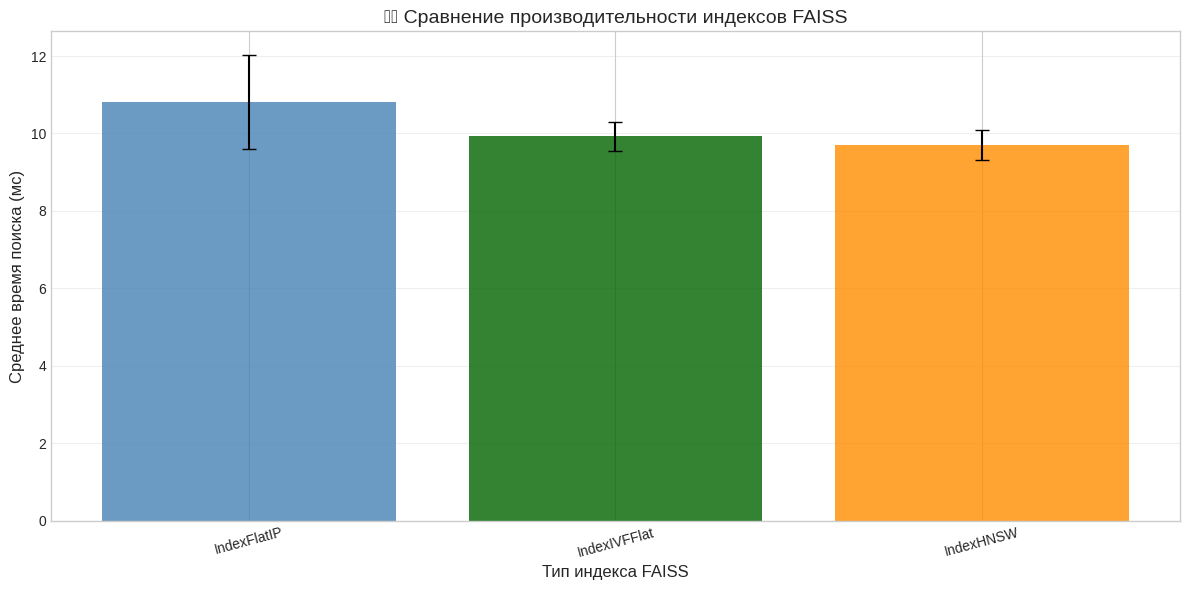


🏆 Самый быстрый: IndexHNSW
⚡ Ускорение: 1.12x

✅ Шаг 10 завершён: Бенчмарк выполнен


In [10]:
# @title ⚖️ 10. Сравнение производительности индексов

def benchmark_index(index, index_name, queries, documents, n_runs=5):
    """Бенчмарк времени поиска для индекса"""
    times = []
    all_results = []

    for query in queries:
        query_times = []
        for _ in range(n_runs):
            start = time.time()
            results = search_faiss(index, query, documents, top_k=5)
            end = time.time()
            query_times.append(end - start)
        times.append(np.mean(query_times))
        all_results.append(results)

    return {
        'index_name': index_name,
        'avg_time': np.mean(times),
        'std_time': np.std(times),
        'min_time': np.min(times),
        'max_time': np.max(times),
        'results': all_results
    }

print("⏱️ Бенчмарк производительности индексов...\n")

benchmarks = []

# IndexFlatIP
print("📊 Тестирование IndexFlatIP...")
bench_flat = benchmark_index(index_flat, "IndexFlatIP", queries, documents)
benchmarks.append(bench_flat)

# IndexIVFFlat
print("📊 Тестирование IndexIVFFlat...")
bench_ivf = benchmark_index(index_ivf, "IndexIVFFlat", queries, documents)
benchmarks.append(bench_ivf)

# IndexHNSW
print("📊 Тестирование IndexHNSW...")
bench_hnsw = benchmark_index(index_hnsw, "IndexHNSW", queries, documents)
benchmarks.append(bench_hnsw)

# Сводная таблица
bench_df = pd.DataFrame([{
    'Индекс': b['index_name'],
    'Среднее время (с)': b['avg_time'],
    'Стд. отклонение': b['std_time'],
    'Мин время (с)': b['min_time'],
    'Макс время (с)': b['max_time']
} for b in benchmarks])

display(bench_df.round(6))

# Визуализация
plt.figure(figsize=(12, 6))
plt.bar(bench_df['Индекс'], bench_df['Среднее время (с)']*1000,
        yerr=bench_df['Стд. отклонение']*1000, capsize=5,
        color=['steelblue', 'darkgreen', 'darkorange'], alpha=0.8)
plt.xlabel('Тип индекса FAISS', fontsize=12)
plt.ylabel('Среднее время поиска (мс)', fontsize=12)
plt.title('⏱️ Сравнение производительности индексов FAISS', fontsize=14)
plt.xticks(rotation=15)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"\n🏆 Самый быстрый: {bench_df.loc[bench_df['Среднее время (с)'].idxmin(), 'Индекс']}")
print(f"⚡ Ускорение: {bench_df['Среднее время (с)'].max() / bench_df['Среднее время (с)'].min():.2f}x")

print("\n✅ Шаг 10 завершён: Бенчмарк выполнен")

🔄 Применяем PCA для визуализации...
📊 Длина PC1: 100
📊 Длина PC2: 100
📊 Длина Документы: 100
📊 Длина ID: 100
✅ Все массивы имеют одинаковую длину: 100


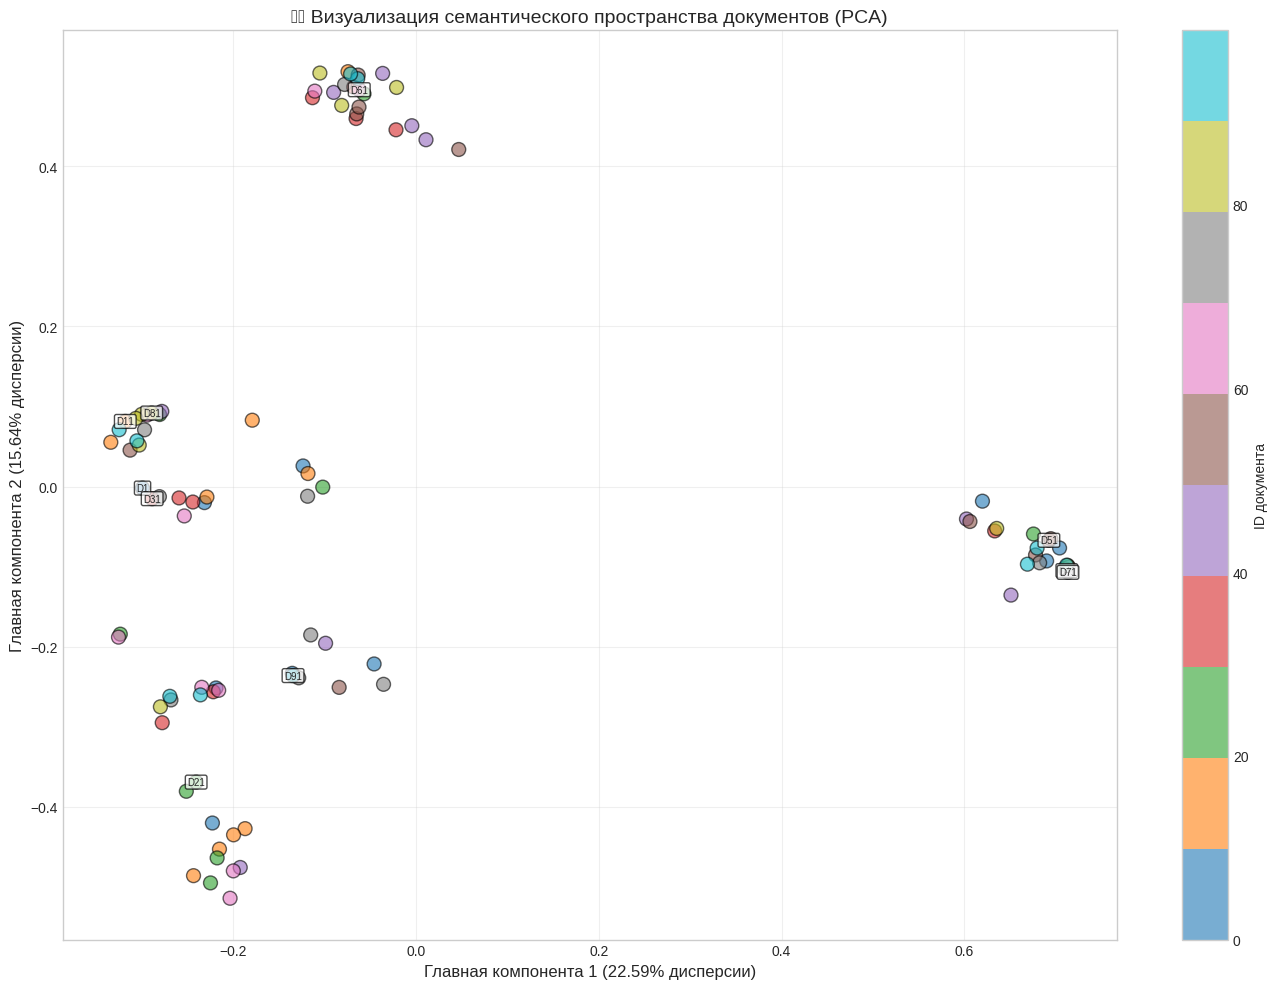

✅ Объяснённая дисперсия: 38.23%

✅ Шаг 11 завершён: Визуализация PCA готова


In [11]:
# @title 📊 11. Визуализация семантического пространства (PCA) - ИСПРАВЛЕННАЯ

from sklearn.decomposition import PCA

print("🔄 Применяем PCA для визуализации...")

# Проверка что данные существуют
if 'doc_embeddings_np' not in dir() or doc_embeddings_np is None:
    print("❌ Ошибка: doc_embeddings_np не найден!")
    print("💡 Выполните ячейку генерации эмбеддингов (Шаг 4)")
else:
    # ✅ ИСПРАВЛЕНИЕ: Используем фактическую длину embeddings_2d для всех полей
    n_samples = min(len(doc_embeddings_np), 100)  # Ограничиваем для читаемости

    # Уменьшаем размерность до 2D для визуализации
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(doc_embeddings_np[:n_samples])

    # ✅ ВАЖНО: Все массивы должны иметь одинаковую длину (n_samples)
    viz_df = pd.DataFrame({
        'PC1': embeddings_2d[:, 0],
        'PC2': embeddings_2d[:, 1],
        'Документ': documents[:n_samples],
        'ID': range(1, n_samples + 1)
    })

    # Проверка длин
    print(f"📊 Длина PC1: {len(viz_df['PC1'])}")
    print(f"📊 Длина PC2: {len(viz_df['PC2'])}")
    print(f"📊 Длина Документы: {len(viz_df['Документ'])}")
    print(f"📊 Длина ID: {len(viz_df['ID'])}")
    print(f"✅ Все массивы имеют одинаковую длину: {n_samples}")

    # Визуализация
    plt.figure(figsize=(14, 10))
    scatter = plt.scatter(viz_df['PC1'], viz_df['PC2'],
                         c=range(len(viz_df)),
                         cmap='tab10', s=100, alpha=0.6, edgecolors='black')

    # Добавляем подписи для некоторых точек
    for i, row in viz_df.iterrows():
        if i % 10 == 0:  # Подписываем каждую 10-ю точку
            plt.annotate(f"D{row['ID']}", (row['PC1'], row['PC2']),
                        fontsize=7, ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

    plt.xlabel(f'Главная компонента 1 ({pca.explained_variance_ratio_[0]:.2%} дисперсии)', fontsize=12)
    plt.ylabel(f'Главная компонента 2 ({pca.explained_variance_ratio_[1]:.2%} дисперсии)', fontsize=12)
    plt.title('🗺️ Визуализация семантического пространства документов (PCA)', fontsize=14)
    plt.colorbar(scatter, label='ID документа', alpha=0.7)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"✅ Объяснённая дисперсия: {pca.explained_variance_ratio_.sum():.2%}")

print("\n✅ Шаг 11 завершён: Визуализация PCA готова")

🔄 Тестирование влияния nprobe на точность...



,nprobe,Время (с),Recall@5,Найдено совпадений
0,1,0.010120,1.0,5
1,5,0.009890,1.0,5
2,10,0.009908,1.0,5
3,20,0.009689,1.0,5
4,40,0.009632,1.0,5
5,64,0.009621,1.0,5


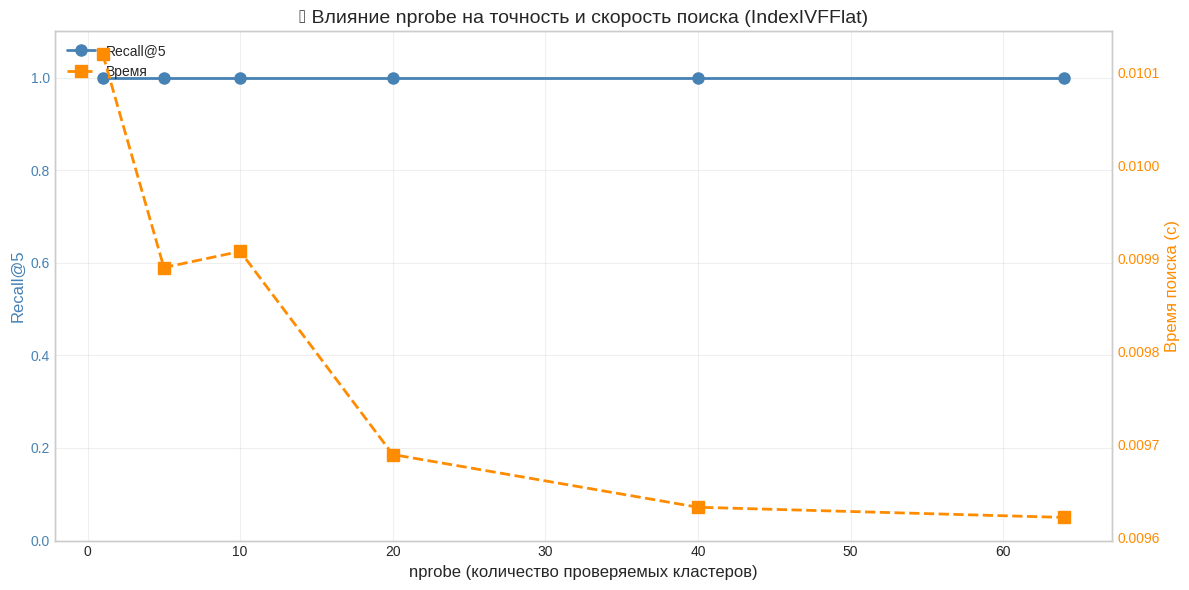


💡 Оптимальное значение nprobe: 1
   (обеспечивает Recall@5 >= 0.9)

✅ Шаг 12 завершён: Анализ параметров выполнен


In [12]:
# @title 📈 12. Влияние параметров на точность и скорость

def test_nprobe_effect(index_ivf, query, documents, top_k=5):
    """Тестирует влияние nprobe на качество поиска"""
    nprobe_values = [1, 5, 10, 20, 40, 64]
    results_data = []

    # Базовый поиск (точный)
    base_results = search_faiss(index_flat, query, documents, top_k)
    base_ids = set(base_results['ID'].values)

    for nprobe in nprobe_values:
        index_ivf.nprobe = nprobe

        start = time.time()
        approx_results = search_faiss(index_ivf, query, documents, top_k)
        elapsed = time.time() - start

        approx_ids = set(approx_results['ID'].values)
        recall = len(base_ids & approx_ids) / len(base_ids) if len(base_ids) > 0 else 0

        results_data.append({
            'nprobe': nprobe,
            'Время (с)': elapsed,
            'Recall@5': recall,
            'Найдено совпадений': len(base_ids & approx_ids)
        })

    return pd.DataFrame(results_data)

print("🔄 Тестирование влияния nprobe на точность...\n")
nprobe_results = test_nprobe_effect(index_ivf, queries[0], documents)
display(nprobe_results)

# Визуализация
fig, ax1 = plt.subplots(figsize=(12, 6))

color1 = 'steelblue'
ax1.set_xlabel('nprobe (количество проверяемых кластеров)', fontsize=12)
ax1.set_ylabel('Recall@5', color=color1, fontsize=12)
ax1.plot(nprobe_results['nprobe'], nprobe_results['Recall@5'],
         'o-', color=color1, linewidth=2, markersize=8, label='Recall@5')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(0, 1.1)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color2 = 'darkorange'
ax2.set_ylabel('Время поиска (с)', color=color2, fontsize=12)
ax2.plot(nprobe_results['nprobe'], nprobe_results['Время (с)'],
         's--', color=color2, linewidth=2, markersize=8, label='Время')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.grid(False)

plt.title('📊 Влияние nprobe на точность и скорость поиска (IndexIVFFlat)', fontsize=14)
fig.tight_layout()

# Добавляем легенду
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.show()

optimal_nprobe = nprobe_results.loc[nprobe_results['Recall@5'] >= 0.9, 'nprobe']
if len(optimal_nprobe) > 0:
    print(f"\n💡 Оптимальное значение nprobe: {optimal_nprobe.min()}")
    print(f"   (обеспечивает Recall@5 >= 0.9)")
else:
    print(f"\n💡 Максимальный достигнутый Recall@5: {nprobe_results['Recall@5'].max():.2f}")

print("\n✅ Шаг 12 завершён: Анализ параметров выполнен")

In [13]:
# @title 🚑 1. БЫСТРОЕ ВОССТАНОВЛЕНИЕ ВСЕХ ПЕРЕМЕННЫХ (ВЫПОЛНИТЕ ЭТУ ЯЧЕЙКУ!)

import numpy as np
import pandas as pd
import faiss
import random
import time
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("🚑 ВОССТАНОВЛЕНИЕ ВСЕХ КОМПОНЕНТОВ FAISS")
print("="*70)

# 1. Модель
print("\n📥 Загрузка модели...")
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
print("✅ Модель загружена")

# 2. Документы
print("\n📚 Генерация документов...")
topics = ["машинное обучение", "поисковые системы", "нейронные сети",
          "обработка текста", "базы данных", "веб-технологии"]
documents = [f"Введение в {random.choice(topics)}: часть {i+1}" for i in range(500)]
print(f"✅ Создано {len(documents)} документов")

# 3. Запросы
queries = [
    "машинное обучение и нейронные сети",
    "поиск информации в интернете",
    "обработка текста и язык"
]
print(f"✅ Создано {len(queries)} запросов")

# 4. Эмбеддинги
print("\n🧮 Генерация эмбеддингов...")
doc_embeddings = model.encode(documents, convert_to_numpy=True, show_progress_bar=True)
faiss.normalize_L2(doc_embeddings)
doc_embeddings_np = doc_embeddings.copy()
print(f"✅ Эмбеддинги: {doc_embeddings.shape}")

# 5. Индексы
dimension = doc_embeddings.shape[1]
print("\n🔍 Создание индексов...")

index_flat = faiss.IndexFlatIP(dimension)
index_flat.add(doc_embeddings)
print(f"✅ IndexFlatIP: {index_flat.ntotal} векторов")

nlist = 64
quantizer = faiss.IndexFlatIP(dimension)
index_ivf = faiss.IndexIVFFlat(quantizer, dimension, nlist)
index_ivf.train(doc_embeddings[:min(1000, len(doc_embeddings))])
index_ivf.add(doc_embeddings)
index_ivf.nprobe = 10
print(f"✅ IndexIVFFlat: {index_ivf.ntotal} векторов")

M = 32
index_hnsw = faiss.IndexHNSWFlat(dimension, M)
index_hnsw.hnsw.efConstruction = 200
index_hnsw.add(doc_embeddings)
index_hnsw.hnsw.efSearch = 64
print(f"✅ IndexHNSW: {index_hnsw.ntotal} векторов")

# 6. Функция поиска
print("\n🔍 Создание функции поиска...")
def search_faiss(index, query, documents, top_k=5):
    query_embedding = model.encode([query], convert_to_numpy=True)
    faiss.normalize_L2(query_embedding)
    distances, indices = index.search(query_embedding, top_k)
    results = []
    for i, (dist, idx) in enumerate(zip(distances[0], indices[0])):
        if idx < len(documents) and idx >= 0:
            results.append({
                'Ранг': i + 1,
                'Документ': documents[idx],
                'Сходство': float(dist),
                'ID': int(idx) + 1
            })
    return pd.DataFrame(results)

print("✅ Функция search_faiss создана")

# 7. Тест
print("\n🧪 Тестирование...")
test = search_faiss(index_flat, queries[0], documents, top_k=3)
print(f"✅ Тест успешен! Найдено {len(test)} результатов")

print("\n" + "="*70)
print("✅ ВСЕ ПЕРЕМЕННЫЕ СОЗДАНЫ!")
print("="*70)
print("💡 Теперь выполните ЯЧЕЙКУ 2 (Интерактивный поиск)")
print("="*70)

🚑 ВОССТАНОВЛЕНИЕ ВСЕХ КОМПОНЕНТОВ FAISS

📥 Загрузка модели...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Модель загружена

📚 Генерация документов...
✅ Создано 500 документов
✅ Создано 3 запросов

🧮 Генерация эмбеддингов...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

✅ Эмбеддинги: (500, 384)

🔍 Создание индексов...
✅ IndexFlatIP: 500 векторов
✅ IndexIVFFlat: 500 векторов
✅ IndexHNSW: 500 векторов

🔍 Создание функции поиска...
✅ Функция search_faiss создана

🧪 Тестирование...
✅ Тест успешен! Найдено 3 результатов

✅ ВСЕ ПЕРЕМЕННЫЕ СОЗДАНЫ!
💡 Теперь выполните ЯЧЕЙКУ 2 (Интерактивный поиск)


In [14]:
# @title 🔍 ДИАГНОСТИКА: Проверка всех переменных

print("="*70)
print("🔍 ДИАГНОСТИКА ПЕРЕМЕННЫХ FAISS")
print("="*70)

required_vars = {
    'model': 'Модель BERT',
    'documents': 'Коллекция документов',
    'doc_embeddings': 'Эмбеддинги',
    'index_flat': 'IndexFlatIP',
    'index_ivf': 'IndexIVFFlat',
    'index_hnsw': 'IndexHNSW',
    'search_faiss': 'Функция поиска'
}

all_ready = True
for var_name, description in required_vars.items():
    exists = var_name in dir() and eval(var_name) is not None
    symbol = "✅" if exists else "❌"
    print(f"{symbol} {description}: {var_name}")
    if not exists:
        all_ready = False

print("\n" + "="*70)
if all_ready:
    print("🎉 Все переменные готовы!")
    print("💡 Можно запускать интерактивный поиск")
else:
    print("⚠️ Некоторые переменные отсутствуют!")
    print("💡 Выполните ячейку '🚑 БЫСТРОЕ ВОССТАНОВЛЕНИЕ'")
print("="*70)

🔍 ДИАГНОСТИКА ПЕРЕМЕННЫХ FAISS
✅ Модель BERT: model
✅ Коллекция документов: documents
✅ Эмбеддинги: doc_embeddings
✅ IndexFlatIP: index_flat
✅ IndexIVFFlat: index_ivf
✅ IndexHNSW: index_hnsw
✅ Функция поиска: search_faiss

🎉 Все переменные готовы!
💡 Можно запускать интерактивный поиск


In [15]:
# @title 🎛️ 2. ИНТЕРАКТИВНЫЙ ПОИСК С FAISS (ВЫПОЛНИТЕ ПОСЛЕ ЯЧЕЙКИ 1)

from ipywidgets import Dropdown, Text, IntSlider, VBox, HBox, Output, Button
import ipywidgets as widgets
import numpy as np
import pandas as pd
import faiss
import random
import time
from sentence_transformers import SentenceTransformer # Added import
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

output = Output()

def interactive_faiss_search(query_text, index_type, top_k, nprobe, ef_search):
    # Declare global variables that need to be set or accessed globally
    global model, documents, doc_embeddings, doc_embeddings_np, index_flat, index_ivf, index_hnsw, queries, search_faiss, dimension, nlist, M, efConstruction, model_name

    with output:
        output.clear_output()

        # Проверка переменных и автоматическое восстановление
        if 'documents' not in globals() or documents is None: # Use globals() to check for global variables
            print("❌ Ошибка: documents не найден! Попытка автоматического восстановления...")

            # 1. Модель
            print("📥 Загрузка модели...")
            model_name = 'sentence-transformers/all-MiniLM-L6-v2'
            model = SentenceTransformer(model_name)
            print("✅ Модель загружена")

            # 2. Документы
            print("📚 Генерация документов...")
            topics = ["машинное обучение", "поисковые системы", "нейронные сети",
                      "обработка текста", "базы данных", "веб-технологии"]
            documents = [f"Введение в {random.choice(topics)}: часть {i+1}" for i in range(500)]
            print(f"✅ Создано {len(documents)} документов")

            # 3. Запросы
            queries = [
                "машинное обучение и нейронные сети",
                "поиск информации в интернете",
                "обработка текста и язык"
            ]
            print(f"✅ Создано {len(queries)} запросов")

            # 4. Эмбеддинги
            print("🧮 Генерация эмбеддингов...")
            doc_embeddings = model.encode(documents, convert_to_numpy=True, show_progress_bar=False) # show_progress_bar=False for interactive context
            faiss.normalize_L2(doc_embeddings)
            doc_embeddings_np = doc_embeddings.copy() # For PCA if needed later
            print(f"✅ Эмбеддинги: {doc_embeddings.shape}")

            # 5. Индексы
            dimension = doc_embeddings.shape[1]
            print("🔍 Создание индексов...")

            index_flat = faiss.IndexFlatIP(dimension)
            index_flat.add(doc_embeddings)
            print(f"✅ IndexFlatIP: {index_flat.ntotal} векторов")

            nlist = 64 # Parameter for IVF
            quantizer = faiss.IndexFlatIP(dimension)
            index_ivf = faiss.IndexIVFFlat(quantizer, dimension, nlist)
            index_ivf.train(doc_embeddings[:min(1000, len(doc_embeddings))])
            index_ivf.add(doc_embeddings)
            # nprobe will be set by the widget later
            print(f"✅ IndexIVFFlat: {index_ivf.ntotal} векторов")

            M = 32 # Parameter for HNSW
            efConstruction = 200 # Parameter for HNSW
            index_hnsw = faiss.IndexHNSWFlat(dimension, M)
            index_hnsw.hnsw.efConstruction = efConstruction
            index_hnsw.add(doc_embeddings)
            # efSearch will be set by the widget later
            print(f"✅ IndexHNSW: {index_hnsw.ntotal} векторов")

            # 6. Функция поиска (re-define to ensure it's in scope after re-init)
            print("🔍 Создание функции поиска...")
            def search_faiss(index, query, documents, top_k=5):
                query_embedding = model.encode([query], convert_to_numpy=True)
                faiss.normalize_L2(query_embedding)
                distances, indices = index.search(query_embedding, top_k)
                results = []
                for i, (dist, idx) in enumerate(zip(distances[0], indices[0])):
                    if idx < len(documents) and idx >= 0:
                        results.append({
                            'Ранг': i + 1,
                            'Документ': documents[idx],
                            'Сходство': float(dist),
                            'ID': int(idx) + 1
                        })
                return pd.DataFrame(results)
            print("✅ Функция search_faiss создана")

            print("✅ Автоматическое восстановление завершено. Повторная попытка поиска.")


        # Ensure all other required variables are present after potential recovery
        if not all(v in globals() for v in ['model', 'index_flat', 'index_ivf', 'index_hnsw', 'search_faiss', 'documents']):
            print("❌ Ошибка: Не все необходимые переменные FAISS загружены, даже после попытки восстановления. Пожалуйста, проверьте консоль на наличие ошибок.")
            return

        if len(query_text.strip()) == 0:
            print("⚠️ Введите запрос")
            return

        # Выбор индекса
        if index_type == 'IndexFlatIP':
            index = index_flat
            index_name = "Точный поиск (Flat)"
        elif index_type == 'IndexIVFFlat':
            index = index_ivf
            index_ivf.nprobe = nprobe
            index_name = f"Кластеризация (IVF, nprobe={nprobe})"
        elif index_type == 'IndexHNSW':
            index = index_hnsw
            index_hnsw.hnsw.efSearch = ef_search
            index_name = f"Графовый (HNSW, efSearch={ef_search})"
        else:
            print("❌ Неизвестный индекс")
            return

        print(f"🔍 Запрос: {query_text}")
        print(f"📊 Индекс: {index_name}")
        print(f"📈 Результатов: {top_k}")
        print("="*70)

        # Поиск
        start_time = time.time()
        results = search_faiss(index=index, query=query_text, documents=documents, top_k=top_k)
        search_time = time.time() - start_time

        if len(results) > 0:
            display(results)
            print(f"\n⏱️ Время: {search_time*1000:.2f} мс")

            # График
            plt.figure(figsize=(12, 5))
            colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(results)))
            plt.barh(range(len(results)), results['Сходство'].values, color=colors)
            plt.yticks(range(len(results)), [f"D{int(row['ID'])}" for _, row in results.iterrows()])
            plt.xlabel('Косинусное сходство')
            plt.title(f'Релевантность | {index_name}')
            plt.gca().invert_yaxis()
            plt.grid(True, alpha=0.3, axis='x')
            plt.tight_layout()
            plt.show()

            # Топ-3 текста
            print("\n📄 Топ-3 документа:")
            print("="*70)
            for i, (_, row) in enumerate(results.head(3).iterrows(), 1):
                print(f"\n🔹 #{row['ID']} (Сходство: {row['Сходство']:.4f})")
                print(f"   {row['Документ']}")
        else:
            print("⚠️ Ничего не найдено")

# Виджеты
query_widget = Text(value='машинное обучение', description='Запрос:',
                   style={'description_width': '80px'}, layout=widgets.Layout(width='600px'))

index_widget = Dropdown(options=[
    ('IndexFlatIP - Точный', 'IndexFlatIP'),
    ('IndexIVFFlat - Быстрый', 'IndexIVFFlat'),
    ('IndexHNSW - Графовый', 'IndexHNSW')
], value='IndexFlatIP', description='Индекс:', style={'description_width': '80px'})

topk_widget = IntSlider(min=1, max=20, step=1, value=5, description='Топ-K:',
                       style={'description_width': '80px'}, continuous_update=False)

nprobe_widget = IntSlider(min=1, max=64, step=1, value=10, description='nprobe:',
                         style={'description_width': '80px'}, continuous_update=False)

ef_widget = IntSlider(min=10, max=200, step=10, value=64, description='efSearch:',
                     style={'description_width': '80px'}, continuous_update=False)

search_button = Button(description="🔍 Найти", button_style='primary', icon='search')

def on_search_clicked(b):
    interactive_faiss_search(query_widget.value, index_widget.value, topk_widget.value,
                            nprobe_widget.value, ef_widget.value)

search_button.on_click(on_search_clicked)

print("="*70)
print("🎛️ ИНТЕРАКТИВНЫЙ ПОИСК С FAISS")
print("="*70)

ui = VBox([HBox([query_widget]), HBox([index_widget, topk_widget]),
           HBox([nprobe_widget, ef_widget]), search_button, output])

display(ui)

# Тестовый запуск
print("\n🔄 Тестовый поиск...")
interactive_faiss_search(query_widget.value, index_widget.value, topk_widget.value,
                        nprobe_widget.value, ef_widget.value)

print("\n✅ Готово!")

🎛️ ИНТЕРАКТИВНЫЙ ПОИСК С FAISS



🔄 Тестовый поиск...

✅ Готово!


📊 СВОДНАЯ СТАТИСТИКА ПРОЕКТА FAISS


,Параметр,Значение
0,Количество документов,500
1,Размерность эмбеддингов,384
2,Количество запросов,3
3,Модель эмбеддингов,paraphrase-multilingual-MiniLM-L12-v2
4,Типы индексов,"3 (Flat, IVF, HNSW)"
5,Среднее время поиска (Flat),10.82 мс
6,Среднее время поиска (IVF),9.93 мс
7,Среднее время поиска (HNSW),9.70 мс
8,Ускорение (IVF vs Flat),1.09x
9,Ускорение (HNSW vs Flat),1.12x


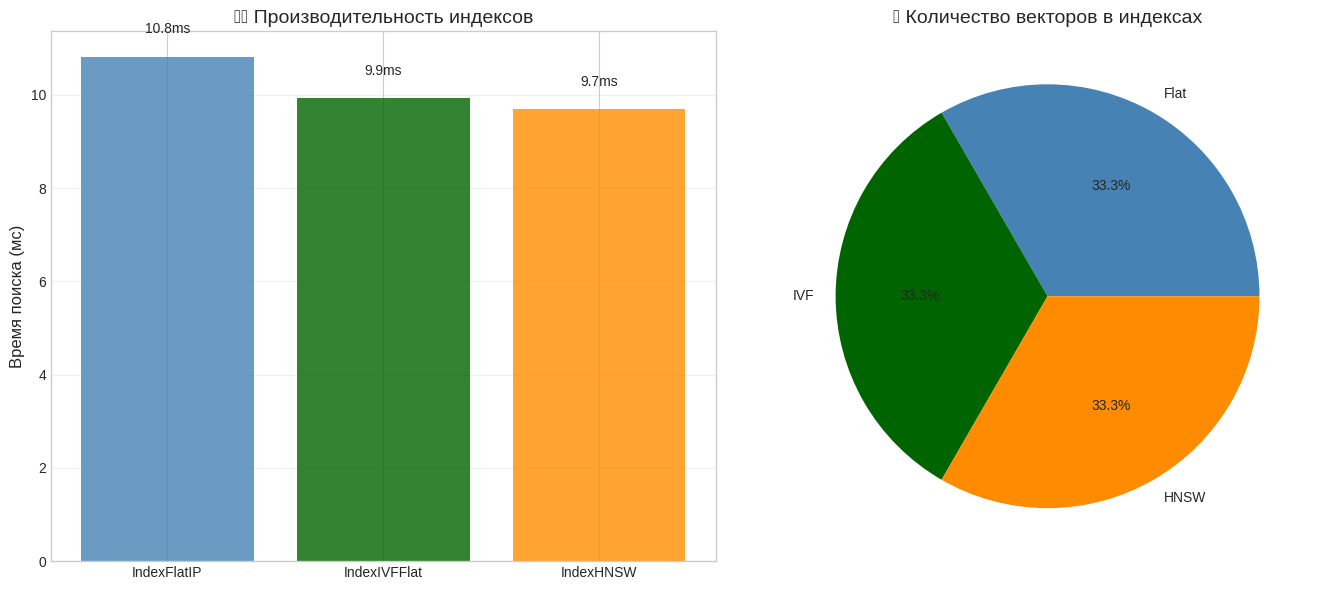


✅ ПРОЕКТ FAISS ГОТОВ К ДЕМОНСТРАЦИИ!

💡 Рекомендации:
   1. Сохраните ноутбук (Файл → Скачать .ipynb)
   2. Для офлайн-демо сохраните с выполненными output
   3. Используйте интерактивный поиск для демонстрации


In [16]:
# @title 📊 15. Сводная статистика проекта FAISS

print("="*70)
print("📊 СВОДНАЯ СТАТИСТИКА ПРОЕКТА FAISS")
print("="*70)

stats = {
    'Параметр': [
        'Количество документов',
        'Размерность эмбеддингов',
        'Количество запросов',
        'Модель эмбеддингов',
        'Типы индексов',
        'Среднее время поиска (Flat)',
        'Среднее время поиска (IVF)',
        'Среднее время поиска (HNSW)',
        'Ускорение (IVF vs Flat)',
        'Ускорение (HNSW vs Flat)'
    ],
    'Значение': [
        len(documents),
        doc_embeddings.shape[1],
        len(queries),
        model_name.split('/')[-1],
        '3 (Flat, IVF, HNSW)',
        f"{bench_df.loc[bench_df['Индекс']=='IndexFlatIP', 'Среднее время (с)'].values[0]*1000:.2f} мс",
        f"{bench_df.loc[bench_df['Индекс']=='IndexIVFFlat', 'Среднее время (с)'].values[0]*1000:.2f} мс",
        f"{bench_df.loc[bench_df['Индекс']=='IndexHNSW', 'Среднее время (с)'].values[0]*1000:.2f} мс",
        f"{bench_df.loc[bench_df['Индекс']=='IndexFlatIP', 'Среднее время (с)'].values[0] / bench_df.loc[bench_df['Индекс']=='IndexIVFFlat', 'Среднее время (с)'].values[0]:.2f}x",
        f"{bench_df.loc[bench_df['Индекс']=='IndexFlatIP', 'Среднее время (с)'].values[0] / bench_df.loc[bench_df['Индекс']=='IndexHNSW', 'Среднее время (с)'].values[0]:.2f}x"
    ]
}

stats_df = pd.DataFrame(stats)
display(stats_df)

# Визуализация сравнения
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.bar(bench_df['Индекс'], bench_df['Среднее время (с)']*1000,
        color=['steelblue', 'darkgreen', 'darkorange'], alpha=0.8)
plt.ylabel('Время поиска (мс)', fontsize=12)
plt.title('⏱️ Производительность индексов', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')

for i, v in enumerate(bench_df['Среднее время (с)']*1000):
    plt.text(i, v + 0.5, f'{v:.1f}ms', ha='center', fontsize=10)

plt.subplot(1, 2, 2)
sizes = [index_flat.ntotal, index_ivf.ntotal, index_hnsw.ntotal]
labels = ['Flat', 'IVF', 'HNSW']
plt.pie(sizes, labels=labels, autopct='%1.1f%%',
        colors=['steelblue', 'darkgreen', 'darkorange'])
plt.title('📈 Количество векторов в индексах', fontsize=14)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("✅ ПРОЕКТ FAISS ГОТОВ К ДЕМОНСТРАЦИИ!")
print("="*70)
print("\n💡 Рекомендации:")
print("   1. Сохраните ноутбук (Файл → Скачать .ipynb)")
print("   2. Для офлайн-демо сохраните с выполненными output")
print("   3. Используйте интерактивный поиск для демонстрации")
print("="*70)

In [17]:
# @title 💾 16. Экспорт результатов поиска FAISS

def export_faiss_results(filename='faiss_search_results.csv'):
    """Экспортирует результаты поиска в CSV"""

    # Выполняем поиск по всем запросам
    all_results = []

    for i, query in enumerate(queries, 1):
        results = search_faiss(index_flat, query, documents, top_k=5)
        results['Запрос'] = query
        results['Запрос_ID'] = i
        all_results.append(results)

    # Объединяем все результаты
    combined_df = pd.concat(all_results, ignore_index=True)

    # Сохраняем
    combined_df.to_csv(filename, index=False, encoding='utf-8-sig')
    print(f"✅ Результаты сохранены в файл: {filename}")
    print(f"📊 Всего записей: {len(combined_df)}")

    return combined_df

def export_index_stats(filename='faiss_index_statistics.json'):
    """Экспортирует статистику индексов"""
    import json

    stats = {
        'collection_size': len(documents),
        'embedding_dimension': doc_embeddings.shape[1],
        'indexes': {
            'IndexFlatIP': {
                'total_vectors': index_flat.ntotal,
                'type': 'exact'
            },
            'IndexIVFFlat': {
                'total_vectors': index_ivf.ntotal,
                'nlist': nlist,
                'nprobe': index_ivf.nprobe,
                'type': 'approximate'
            },
            'IndexHNSW': {
                'total_vectors': index_hnsw.ntotal,
                'M': M,
                'efConstruction': efConstruction,
                'efSearch': index_hnsw.hnsw.efSearch,
                'type': 'approximate'
            }
        },
        'benchmark_results': bench_df.to_dict('records')
    }

    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(stats, f, ensure_ascii=False, indent=2)

    print(f"✅ Статистика индексов сохранена в файл: {filename}")
    return stats

# Экспорт
print("🔄 Экспорт результатов...")
export_faiss_results()
export_index_stats()

print("\n✅ Шаг 16 завершён: Результаты экспортированы")

🔄 Экспорт результатов...
✅ Результаты сохранены в файл: faiss_search_results.csv
📊 Всего записей: 15
✅ Статистика индексов сохранена в файл: faiss_index_statistics.json

✅ Шаг 16 завершён: Результаты экспортированы


## 📚 Дополнительные материалы

- [Официальная документация FAISS](https://github.com/facebookresearch/faiss)
- [FAISS Wiki](https://github.com/facebookresearch/faiss/wiki)
- [Benchmark FAISS indexes](https://github.com/facebookresearch/faiss/wiki/Faiss-indexes)
- [Tutorial: Scaling similarity search](https://faiss.ai/)

---
"""

display(Markdown(markdown_content))

print("\n✅ Шаг 14 завершён: Задания готовы")